# Lexical Candidate Re-ranking Baseline

A shopper who searches for:

> **"phone case samsung galaxy s8 otterbox"**

expects the most useful products to appear near the top of the results.

The ESCI data used here does not ask us to search the full Amazon catalog. Each query already comes with a small set of judged candidate products. The task is therefore **candidate re-ranking**: reorder those products so that the most relevant ones appear first.

```text
Query: "phone case samsung galaxy s8 otterbox"
                    ↓
         Candidate products already given
                    ↓
          Random / TF-IDF / BM25
                    ↓
              Reordered list
                    ↓
        Are the useful products near the top?
```

That distinction is important:

- **Retrieval** decides which products enter the candidate set.
- **Re-ranking** decides how an existing candidate set should be ordered.

The analysis uses three simple lexical baselines:

- Random ordering
- TF-IDF cosine similarity
- BM25

These methods rely only on text overlap; there is no learned ranking model at this stage. The purpose is to establish a trustworthy reference point, evaluate ranking correctly, and identify where a fixed lexical scoring rule begins to break down.

Products labeled **Exact** should generally appear above **Irrelevant** products, while **Substitutes** and **Complements** provide intermediate relevance information.

> Reusable ranking logic lives in `src/`. This notebook focuses on the behavior and interpretation of the ranking experiment.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.constants import BINARY_RELEVANT_LABELS, DEFAULT_K, RELEVANCE_GAIN, SEED
from src.data.load_data import PROCESSED_DIR
from src.retrieval.text import tokenize

val_path = PROCESSED_DIR / "project_validation.parquet"
stats_path = PROCESSED_DIR / "dataset_stats.json"
summary_path = ROOT / "artifacts" / "metrics" / "baseline_summary.json"
per_query_path = ROOT / "artifacts" / "metrics" / "baseline_per_query.csv"

required = [val_path, stats_path, summary_path, per_query_path]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Baseline artifacts are missing. Run `python scripts/prepare_data.py` and "
        "`python scripts/run_baseline.py` first. Missing:\n- " + "\n- ".join(missing)
    )

validation = pd.read_parquet(val_path)
stats = json.loads(stats_path.read_text())
summary = json.loads(summary_path.read_text())
per_query = pd.read_csv(per_query_path)

print(f"Validation rows: {len(validation):,}")
print(f"Validation queries: {validation['query_id'].nunique():,}")
print(f"Seed: {SEED}")

Validation rows: 63,038
Validation queries: 3,134
Seed: 1234


## 1. A row in the ranking data

Each row represents:

> **one query + one candidate product + one relevance judgment**

The ESCI labels have a direct shopping interpretation:

| Label | Meaning | Shopping intuition |
|---|---|---|
| **E — Exact** | Directly satisfies the query | Essentially what the shopper asked for |
| **S — Substitute** | Reasonable alternative | Could be bought instead |
| **C — Complement** | Related, but not a replacement | An accessory or related item |
| **I — Irrelevant** | Does not satisfy the intent | Wrong result |

The evaluation uses these labels in two ways:

- **NDCG** uses graded relevance with gains `E=3, S=2, C=1, I=0`.
- **Recall** and **MRR** treat only `E` and `S` as relevant hits.

Looking at one real query first makes the structure of the ranking problem concrete before moving to aggregate results.

In [2]:
# Prefer a recognizable disagreement query if it is present.
preferred_query = "phone case samsung galaxy s8 otterbox"

example_rows = validation.loc[
    validation["query"].str.lower().eq(preferred_query.lower()),
    ["query_id", "query", "product_id", "product_title", "esci_label"],
]

if example_rows.empty:
    # Fallback: choose a query with enough candidates to make the structure visible.
    fallback_qid = (
        validation.groupby("query_id")
        .size()
        .sort_values(ascending=False)
        .index[0]
    )
    example_rows = validation.loc[
        validation["query_id"].eq(fallback_qid),
        ["query_id", "query", "product_id", "product_title", "esci_label"],
    ]

print("One query-product candidate set:")
display(example_rows.head(10).reset_index(drop=True))

One query-product candidate set:


,query_id,query,product_id,product_title,esci_label
0,79518,phone case samsung galaxy s8 otterbox,B084GG77FD,OtterBox Defender Screenless Series Rugged Cas...,E
1,79518,phone case samsung galaxy s8 otterbox,B0844QHRKH,OtterBox Defender Series Case for Samsung Gala...,E
2,79518,phone case samsung galaxy s8 otterbox,B0838XHGTL,OtterBox Commuter Series Case for Samsung Gala...,E
3,79518,phone case samsung galaxy s8 otterbox,B07MMX1CBD,Rugged Protection OtterBox Defender Case for S...,I
4,79518,phone case samsung galaxy s8 otterbox,B07GZ5S6W5,OtterBox Commuter Series Case for Samsung Gala...,I
5,79518,phone case samsung galaxy s8 otterbox,B07792648P,SUPCASE Full-Body Rugged Holster Case for Sams...,S
6,79518,phone case samsung galaxy s8 otterbox,B071NFTWKW,Spigen Tough Armor Galaxy S8 Designed for Sams...,S
7,79518,phone case samsung galaxy s8 otterbox,B06XXB97TM,ZIZO Bolt Series for Samsung Galaxy S8 Case Mi...,S
8,79518,phone case samsung galaxy s8 otterbox,B06XDW9WCP,Otterbox Symmetry Clear Series for Samsung Gal...,E
9,79518,phone case samsung galaxy s8 otterbox,B06XD3W3WK,OTTERBOX COMMUTER SERIES for Samsung Galaxy S8...,E


### Why evaluation is query-level

The rows above belong to the same ranking problem: they are candidate products competing for positions within a single query.

For that reason, splitting and evaluation are performed by `query_id`, not by individual query-product rows. If products from the same query were scattered across training and validation, information about the same candidate set could appear on both sides of the split.

This notebook reads artifacts created by `prepare_data.py` and `run_baseline.py`. The official test queries remain untouched; all reported results come from the project validation split.

## 2. Ranking is different from classification

A compact example makes the distinction visible. Suppose a query has six candidate products and a ranker returns:

| Rank | Product intuition | ESCI | Gain |
|---:|---|:---:|---:|
| 1 | Wrong accessory | I | 0 |
| 2 | Reasonable alternative | S | 2 |
| 3 | Related accessory | C | 1 |
| 4 | Exact requested product | E | 3 |
| 5 | Another substitute | S | 2 |
| 6 | Wrong product | I | 0 |

Useful products are present, but the **Exact** match is buried at rank 4. A binary relevant/irrelevant prediction would miss an important part of the problem: **where** the useful products appear.

To keep the arithmetic compact, use **K = 3** in this example. The actual evaluation uses **K = 10**.

### Recall@3

`E` and `S` count as relevant hits. There are three relevant products in the full list—at ranks 2, 4, and 5—but only one appears in the top 3:

\[
Recall@3 = \frac{1}{3} \approx 0.333
\]

### MRR

The first relevant result appears at rank 2:

\[
MRR = \frac{1}{2} = 0.5
\]

### NDCG@3

NDCG uses both **graded relevance** and **rank position**. With gains `E=3, S=2, C=1, I=0`,

\[
DCG@3 = \sum_{r=1}^{3}\frac{gain_r}{\log_2(r+1)}.
\]

The observed top-three gains are `[0, 2, 1]`:

\[
DCG@3 \approx 1.762
\]

while the ideal ordering would begin `[3, 2, 1]`:

\[
IDCG@3 \approx 4.762.
\]

Therefore,

\[
NDCG@3 \approx 0.370.
\]

Moving the Exact and Substitute products upward would improve all three metrics, but for different reasons: NDCG rewards graded quality near the top, Recall measures coverage of relevant items, and MRR emphasizes how quickly the first relevant result appears.

## 3. Data and evaluation design

The validation data is summarized with a small set of checks that matter directly for ranking:

- number of queries,
- candidate products per query,
- distribution of E/S/C/I labels,
- missing product titles,
- duplicate query-product pairs.

The development split is query-level, so each query's entire candidate list remains together. The official test set is reserved and not used for model iteration.

In [3]:
candidate_sizes = validation.groupby("query_id").size()

overview = pd.Series({
    "rows": len(validation),
    "queries": validation["query_id"].nunique(),
    "unique products": validation["product_id"].nunique(),
    "median candidates/query": candidate_sizes.median(),
    "mean candidates/query": candidate_sizes.mean(),
    "missing product titles": validation["product_title"].isna().sum(),
    "duplicate query-product pairs": validation.duplicated(["query_id", "product_id"]).sum(),
}, name="value")

display(overview.to_frame())

label_table = (
    validation["esci_label"]
    .value_counts()
    .reindex(["E", "S", "C", "I"], fill_value=0)
    .rename("count")
    .to_frame()
)
label_table["share"] = label_table["count"] / label_table["count"].sum()
display(label_table)

,value
rows,63038.000000
queries,3134.000000
unique products,60321.000000
median candidates/query,16.000000
mean candidates/query,20.114231
missing product titles,0.000000
duplicate query-product pairs,0.000000


,count,share
esci_label,,
E,27013,0.428519
S,22359,0.354691
C,2895,0.045925
I,10771,0.170865


## 4. Candidate-set density and the Random baseline

Before interpreting NDCG, it is useful to examine how much relevant material is already present in each candidate set.

The ESCI candidates are **not random products from the full catalog**. They are a judged candidate pool. When a large share of those products is already labeled Exact or Substitute, even a random shuffle can place several relevant products near the top by chance.

This makes candidate density part of the interpretation of every baseline result that follows.

,n_candidates,relevant_share,exact_share
mean,20.114,0.790,0.427
25%,16.000,0.654,0.215
50%,16.000,0.875,0.400
75%,16.000,1.000,0.625


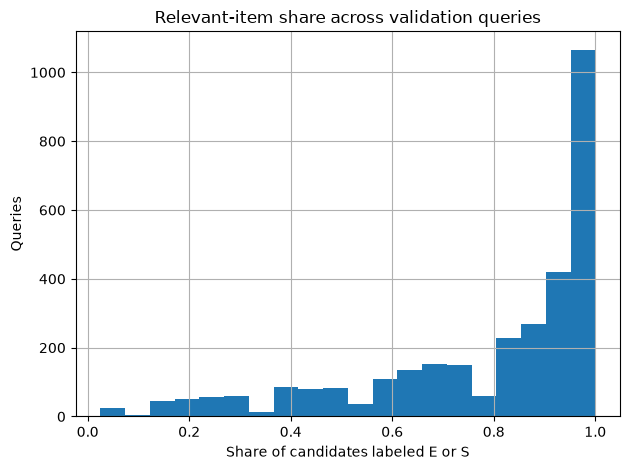

In [4]:
query_profile = (
    validation.assign(
        is_relevant=validation["esci_label"].isin(BINARY_RELEVANT_LABELS),
        is_exact=validation["esci_label"].eq("E"),
    )
    .groupby("query_id")
    .agg(
        n_candidates=("product_id", "size"),
        relevant_share=("is_relevant", "mean"),
        exact_share=("is_exact", "mean"),
    )
)

display(
    query_profile[["n_candidates", "relevant_share", "exact_share"]]
    .describe()
    .loc[["mean", "25%", "50%", "75%"]]
    .round(3)
)

ax = query_profile["relevant_share"].hist(bins=20)
ax.set(
    title="Relevant-item share across validation queries",
    xlabel="Share of candidates labeled E or S",
    ylabel="Queries",
)
plt.tight_layout()
plt.show()

### Candidate-density interpretation

In this validation set:

- the average query has about **20 candidates**,
- the median query has **16 candidates**,
- the median query has about **87.5% E/S candidates**,
- and the mean E/S share is about **79%**.

This context explains why the Random baseline later reaches roughly **0.76 NDCG@10**.

That number does not make Random a useful ranking strategy. It tells us that the benchmark candidate pool is already rich in relevant products. A random ordering can therefore look numerically respectable without understanding the query at all.

The implication is important: strong scores in this experiment measure how well we **reorder an already useful candidate set**. They do not demonstrate an ability to retrieve good products from the full Amazon catalog.

## 5. Three lexical baselines

All three methods receive the same candidate products. Only the ordering rule changes.

### Random

Random ignores the text and shuffles the candidates. A fixed seed makes the result reproducible. It serves as a calibration floor: how good can the ranking metrics look with no relevance signal at all?

### TF-IDF cosine similarity

TF-IDF scores how strongly the query and product title align in weighted term space.

In practical terms:

- shared words increase similarity,
- words that are uncommon within the candidate set receive more weight,
- cosine similarity measures how closely the query and title representations point in the same direction.

### BM25

BM25 is also lexical, but it handles term frequency and document length differently. Repeated terms and longer titles are treated with a different weighting scheme than plain TF-IDF.

### Candidate-local lexical statistics

In this implementation, TF-IDF and BM25 statistics are computed **within each query's candidate set**, not over the entire Amazon catalog.

So a “rare” word means:

> rare among these candidate titles,

rather than:

> rare across all Amazon products.

That detail matters when interpreting disagreements between the two methods. Their average performance can be close while the local weighting of particular terms produces different rankings for individual queries.

Detailed formulas are kept out of the notebook because the reusable implementation belongs in `src/retrieval/`; the analysis here focuses on model behavior.

In [5]:
mean_table = pd.DataFrame(summary["mean_table"]).T
metric_cols = [f"ndcg@{DEFAULT_K}", f"recall@{DEFAULT_K}", "mrr"]

results = mean_table[metric_cols].copy()
results.columns = [f"NDCG@{DEFAULT_K}", f"Recall@{DEFAULT_K}", "MRR"]
display(results.round(4))

best_ndcg_model = results[f"NDCG@{DEFAULT_K}"].idxmax()
print(f"Best mean NDCG@{DEFAULT_K}: {best_ndcg_model}")

,NDCG@10,Recall@10,MRR
random,0.7611,0.5684,0.8757
tfidf,0.8173,0.5922,0.9060
bm25,0.8124,0.5906,0.8988


Best mean NDCG@10: tfidf


### Baseline performance

The aggregate results support three conclusions.

First, **TF-IDF and BM25 both outperform Random**, so lexical overlap contains real ranking signal.

Second, the improvement is **modest**, which is consistent with the relevance-dense candidate pools described above.

Third, **TF-IDF is slightly ahead on mean NDCG@10, but BM25 is very close**.

The aggregate means are useful as a reference point, but they do not tell us whether the two lexical methods succeed and fail on the same queries. That requires a paired query-level comparison.

## 6. Similar averages can hide different rankings

Because TF-IDF and BM25 rank the same candidate set for each query, their performance can be compared directly at the query level:

\[
\Delta_q = NDCG_q(\text{BM25}) - NDCG_q(\text{TF-IDF}).
\]

- Positive values indicate a BM25 advantage.
- Negative values indicate a TF-IDF advantage.
- Zero indicates a tie.

This paired view shows whether a small difference in mean performance reflects broadly similar behavior or a large number of offsetting wins and losses.

,queries
BM25 wins,1017
TF-IDF wins,1271
Ties,846


Mean paired difference: -0.0049
Median paired difference: 0.0


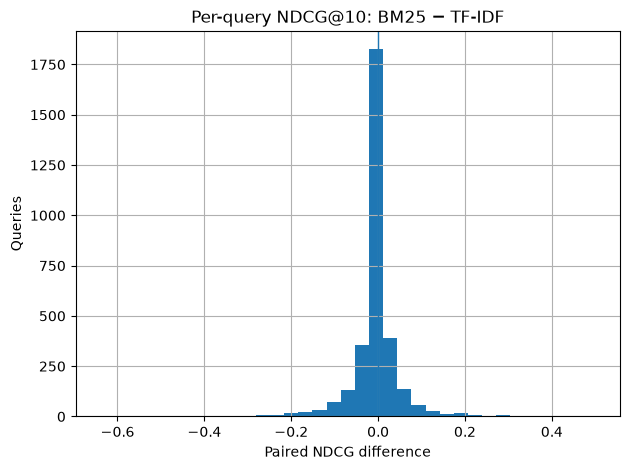

In [6]:
bm25_col = f"ndcg@{DEFAULT_K}_bm25"
tfidf_col = f"ndcg@{DEFAULT_K}_tfidf"

paired = per_query[["query_id", bm25_col, tfidf_col]].copy()
paired["delta_ndcg"] = paired[bm25_col] - paired[tfidf_col]

tol = 1e-12
wins = pd.Series({
    "BM25 wins": (paired["delta_ndcg"] > tol).sum(),
    "TF-IDF wins": (paired["delta_ndcg"] < -tol).sum(),
    "Ties": (paired["delta_ndcg"].abs() <= tol).sum(),
})
display(wins.to_frame("queries"))

print("Mean paired difference:", round(paired["delta_ndcg"].mean(), 4))
print("Median paired difference:", round(paired["delta_ndcg"].median(), 4))

ax = paired["delta_ndcg"].hist(bins=35)
ax.axvline(0, linewidth=1)
ax.set(
    title=f"Per-query NDCG@{DEFAULT_K}: BM25 − TF-IDF",
    xlabel="Paired NDCG difference",
    ylabel="Queries",
)
plt.tight_layout()
plt.show()

### Query-level interpretation

The average difference is small, but the two methods do **not** produce interchangeable rankings.

In the current validation run:

- BM25 wins on about **1,017 queries**,
- TF-IDF wins on about **1,271 queries**,
- about **846 queries** are ties,
- and the mean paired NDCG difference is only about **−0.005**.

So the near tie in aggregate NDCG is the result of many query-level differences balancing out. This makes the disagreement cases more informative than the overall mean alone.

## 7. Does query length explain the difference?

A one-word query such as `"laptop"` carries less explicit information than a longer query containing a brand, model number, or product attribute.

As a simple diagnostic, queries are grouped into:

- 1 token,
- 2–3 tokens,
- 4+ tokens.

This is a descriptive comparison rather than a causal one. The goal is to see whether query length provides an obvious explanation for the relative behavior of TF-IDF and BM25.

In [7]:
query_meta = (
    validation.drop_duplicates("query_id")[["query_id", "query"]]
    .assign(query_tokens=lambda d: d["query"].map(lambda q: len(tokenize(q))))
)

query_meta["query_length_group"] = pd.cut(
    query_meta["query_tokens"],
    bins=[0, 1, 3, np.inf],
    labels=["1 token", "2–3 tokens", "4+ tokens"],
)

by_length = (
    paired.merge(query_meta, on="query_id", how="left")
    .groupby("query_length_group", observed=True)
    .agg(
        queries=("query_id", "size"),
        bm25_ndcg=(bm25_col, "mean"),
        tfidf_ndcg=(tfidf_col, "mean"),
        mean_delta=("delta_ndcg", "mean"),
    )
)

display(by_length.round(4))

,queries,bm25_ndcg,tfidf_ndcg,mean_delta
query_length_group,,,,
1 token,100,0.7855,0.7910,-0.0055
2–3 tokens,1377,0.8193,0.8252,-0.0059
4+ tokens,1657,0.8083,0.8123,-0.0040


### Query-length result

Query length does **not** substantially change the relative ordering of the two methods.

TF-IDF is slightly ahead in all three groups, while the BM25-minus-TF-IDF difference remains small throughout. The data therefore does not support a simple rule such as:

> “BM25 is better for long queries.”

The more useful next step is to inspect the actual candidate products for queries where the methods disagree sharply.

## 8. Inspecting concrete disagreement cases

A large NDCG difference tells us **that** two ranking methods disagree, but not **why**.

The most informative cases are those where one method performs substantially better than the other. Examining the product titles and ESCI labels makes it possible to see which lexical signals each scoring rule is rewarding.

The next cell identifies one strong BM25 win and one strong TF-IDF win, then reads the per-item ranking artifacts produced by the baseline pipeline.

> Ranking logic remains in `src/`; the notebook reads saved ranking outputs rather than re-implementing the methods inline.

In [8]:
query_lookup = validation.drop_duplicates("query_id")[["query_id", "query"]]
disagreements = paired.merge(query_lookup, on="query_id", how="left")

show_cols = ["query_id", "query", bm25_col, tfidf_col, "delta_ndcg"]

bm25_case = disagreements.nlargest(1, "delta_ndcg").iloc[0]
tfidf_case = disagreements.nsmallest(1, "delta_ndcg").iloc[0]

print("Strong BM25 win:")
display(pd.DataFrame([bm25_case[show_cols]]).round(4))

print("Strong TF-IDF win:")
display(pd.DataFrame([tfidf_case[show_cols]]).round(4))

example_dir = ROOT / "artifacts" / "examples"

def _read_example_files(directory: Path) -> pd.DataFrame:
    frames = []
    if not directory.exists():
        return pd.DataFrame()

    for path in sorted(directory.iterdir()):
        try:
            if path.suffix.lower() == ".csv":
                df = pd.read_csv(path)
            elif path.suffix.lower() in {".parquet", ".pq"}:
                df = pd.read_parquet(path)
            elif path.suffix.lower() == ".json":
                df = pd.read_json(path)
            else:
                continue
        except Exception:
            continue

        if df.empty:
            continue

        df = df.copy()
        df["_source_file"] = path.name

        # If the artifact does not have an explicit model column,
        # the filename may still tell us which ranker produced it.
        lower_name = path.name.lower()
        if "model" not in df.columns and "ranker" not in df.columns and "method" not in df.columns:
            if "bm25" in lower_name:
                df["_model_from_file"] = "bm25"
            elif "tfidf" in lower_name or "tf_idf" in lower_name:
                df["_model_from_file"] = "tfidf"

        frames.append(df)

    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

saved_examples = _read_example_files(example_dir)

required_example_cols = {"query_id", "product_title", "esci_label"}

if saved_examples.empty or not required_example_cols.issubset(saved_examples.columns):
    print(
        "\nPer-item ranked example artifacts were not found in a readable tabular form.\n"
        "That is a pipeline/artifact issue, not a reason to rebuild ranking logic in this notebook.\n"
        "Persist top-ranked examples from run_baseline.py with at least:\n"
        "query_id, model/method, predicted_rank, product_title, esci_label, and score."
    )
else:
    saved_examples["_qid_str"] = saved_examples["query_id"].astype(str)

    rank_candidates = [
        c for c in ["predicted_rank", "rank", "position"] if c in saved_examples.columns
    ]
    rank_col = rank_candidates[0] if rank_candidates else None

    model_candidates = [
        c for c in ["model", "ranker", "method", "baseline", "_model_from_file"]
        if c in saved_examples.columns
    ]
    model_col = model_candidates[0] if model_candidates else None

    display_cols = [
        c for c in [
            model_col, rank_col, "product_title", "esci_label",
            "bm25_score", "tfidf_score", "score", "_source_file"
        ]
        if c is not None and c in saved_examples.columns
    ]

    for label, row in [("BM25 win", bm25_case), ("TF-IDF win", tfidf_case)]:
        qid = str(row["query_id"])
        subset = saved_examples.loc[saved_examples["_qid_str"].eq(qid)].copy()

        print(f"\n{label}: {row['query']!r}")

        if subset.empty:
            print("No saved per-item ranking artifact found for this query.")
            continue

        if rank_col is not None:
            subset = subset.sort_values(
                [model_col, rank_col] if model_col is not None else [rank_col]
            )

        display(subset[display_cols].head(20))

Strong BM25 win:


,query_id,query,ndcg@10_bm25,ndcg@10_tfidf,delta_ndcg
1340,46493,gold slave for 15 years,1.0,0.5,0.5


Strong TF-IDF win:


,query_id,query,ndcg@10_bm25,ndcg@10_tfidf,delta_ndcg
2886,106401,ugly stik custom,0.1997,0.8391,-0.6395



BM25 win: 'gold slave for 15 years'
No saved per-item ranking artifact found for this query.

TF-IDF win: 'ugly stik custom'


,_model_from_file,product_title,esci_label,bm25_score,tfidf_score,_source_file
0,bm25,Wild River CLC WT3505 Tackle Tek Mission Light...,I,0.0,0.000000,query_106401_tfidf_bm25_disagree.csv
1,bm25,Wild River by CLC WT3503 Tackle Tek Recon Ligh...,I,0.0,0.000000,query_106401_tfidf_bm25_disagree.csv
2,bm25,Wild River CLC WCN503 Tackle Tek Recon LED Lig...,I,0.0,0.000000,query_106401_tfidf_bm25_disagree.csv
3,bm25,Shakespeare USSP662M/35CBO Ugly Stik GX2 2-Pie...,E,0.0,0.192186,query_106401_tfidf_bm25_disagree.csv
4,bm25,Wild River CLC WN3508 Multi-Tackle Small Backp...,I,0.0,0.000000,query_106401_tfidf_bm25_disagree.csv
5,bm25,Wild River CLC WT3606 Multi-Tackle Large Backp...,I,0.0,0.000000,query_106401_tfidf_bm25_disagree.csv
6,bm25,Wild River Nomad CLC WCN604 Tackle Tek Nomad L...,I,0.0,0.000000,query_106401_tfidf_bm25_disagree.csv
7,bm25,Ugly Stik GX2 Baitcast Combo,E,0.0,0.421226,query_106401_tfidf_bm25_disagree.csv
8,bm25,Shakespeare Ugly Stik Logo Hoodie,I,0.0,0.451177,query_106401_tfidf_bm25_disagree.csv
9,bm25,Shakespeare Ugly Stik Logo Hoodie,I,0.0,0.451177,query_106401_tfidf_bm25_disagree.csv


### Interpreting disagreement cases

Several patterns are useful when reading these examples:

- exact phrase matches,
- brand or model tokens,
- generic words that create misleading overlap,
- long titles that change term weighting,
- cases where the product meaning is clear even though the query and title share few words.

Not every failure should have the same explanation. The value of this inspection is to identify recurring signals that a more flexible ranking model could combine explicitly.

## 9. Conclusions

The lexical baselines provide a useful reference point for the ranking problem.

### Lexical methods improve on Random, but modestly

Random reaches about **0.761 NDCG@10**, while TF-IDF and BM25 reach about **0.817** and **0.812**. The relatively high Random score is largely a consequence of candidate sets that already contain many relevant products.

### TF-IDF and BM25 are close on average, but not query by query

TF-IDF has the higher mean NDCG@10 in this validation run, but the average difference is only about **0.005**. At the query level, both methods record many wins and losses, so the similar aggregate scores hide meaningfully different ranking behavior.

### Query length does not explain the difference

TF-IDF remains slightly ahead for 1-token, 2–3-token, and 4+-token queries. The gap is small in every group, so query length alone does not explain the disagreements.

### The main limitation is the fixed lexical scoring rule

This experiment evaluates **re-ranking of judged candidate sets**, not retrieval from the full product catalog. Within that constrained problem, both methods depend on word overlap and fixed term-weighting rules.

They cannot flexibly learn that signals such as:

- BM25 score,
- TF-IDF similarity,
- exact phrase match,
- brand match,
- token coverage,
- or other product attributes

may matter differently across queries.

That limitation motivates the next modeling step: a **learning-to-rank model** that combines several query-product signals into a learned relevance score.

The baseline has therefore done its job. It establishes a reproducible floor, clarifies the evaluation framework, and exposes the specific weaknesses that a learned ranker should address.